# Exploratory Data Analysis & Readmission Prototyping
**AegisCare Clinical Decision Support System (CDSS)**

This notebook covers:
1. Cohort ingestion and clinical attribute inspection
2. Length of Stay (LOS) derivation and chronic disease distribution
3. Risk factor cross-tabulation and readmission prevalence
4. Baseline prototype validation curves

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Visual aesthetics
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.sans-serif"] = "Arial"

In [2]:
# Ingest processed cohort data
data_path = "../data/processed/clean_data.parquet"

if not os.path.exists(data_path):
    # Fallback to local execution directory
    data_path = "data/processed/clean_data.parquet"

df = pd.read_parquet(data_path)
print(f"Total Cohort Records: {len(df):,}")
print("Column Specifications:")
df.info()

Total Cohort Records: 55,500
Column Specifications:
<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   name                55500 non-null  str           
 1   age                 55500 non-null  int64         
 2   gender              55500 non-null  str           
 3   blood_type          55500 non-null  str           
 4   medical_condition   55500 non-null  str           
 5   date_of_admission   55500 non-null  datetime64[us]
 6   doctor              55500 non-null  str           
 7   hospital            55500 non-null  str           
 8   insurance_provider  55500 non-null  str           
 9   billing_amount      55500 non-null  float64       
 10  room_number         55500 non-null  int64         
 11  admission_type      55500 non-null  str           
 12  discharge_date      55500 non-null  datetime64[us]
 13  medic

In [3]:
# Summary statistics for numerical variables
print("--- Continuous Variables Summary ---")
display(df[['age', 'billing_amount', 'length_of_stay']].describe().T)

print("\n--- Target Readmission Class Distribution ---")
class_dist = pd.DataFrame({
    'Count': df['readmission'].value_counts(),
    'Proportion (%)': (df['readmission'].value_counts(normalize=True) * 100).round(2)
})
display(class_dist)

--- Continuous Variables Summary ---


,count,mean,std,min,25%,50%,75%,max
age,55500.0,51.539459,19.602454,13.00000,35.000000,52.000000,68.000000,89.000000
billing_amount,55500.0,25539.316097,14211.454431,-2008.49214,13241.224652,25538.069376,37820.508436,52764.276736
length_of_stay,55500.0,15.509009,8.659600,1.00000,8.000000,15.000000,23.000000,30.000000



--- Target Readmission Class Distribution ---


,Count,Proportion (%)
readmission,,
0,50141,90.34
1,5359,9.66


C:\Users\hp\AppData\Local\Temp\ipykernel_31564\3166611061.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cond_rates.index, y=cond_rates.values, ax=axes[0], palette="Blues_r")
C:\Users\hp\AppData\Local\Temp\ipykernel_31564\3166611061.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='readmission', y='length_of_stay', data=df, ax=axes[1], palette=['#38A169', '#E53E3E'])
C:\Users\hp\AppData\Local\Temp\ipykernel_31564\3166611061.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(['Discharged (0)', 'Readmitted (1)'])
C:\Users\hp\AppData\Lo

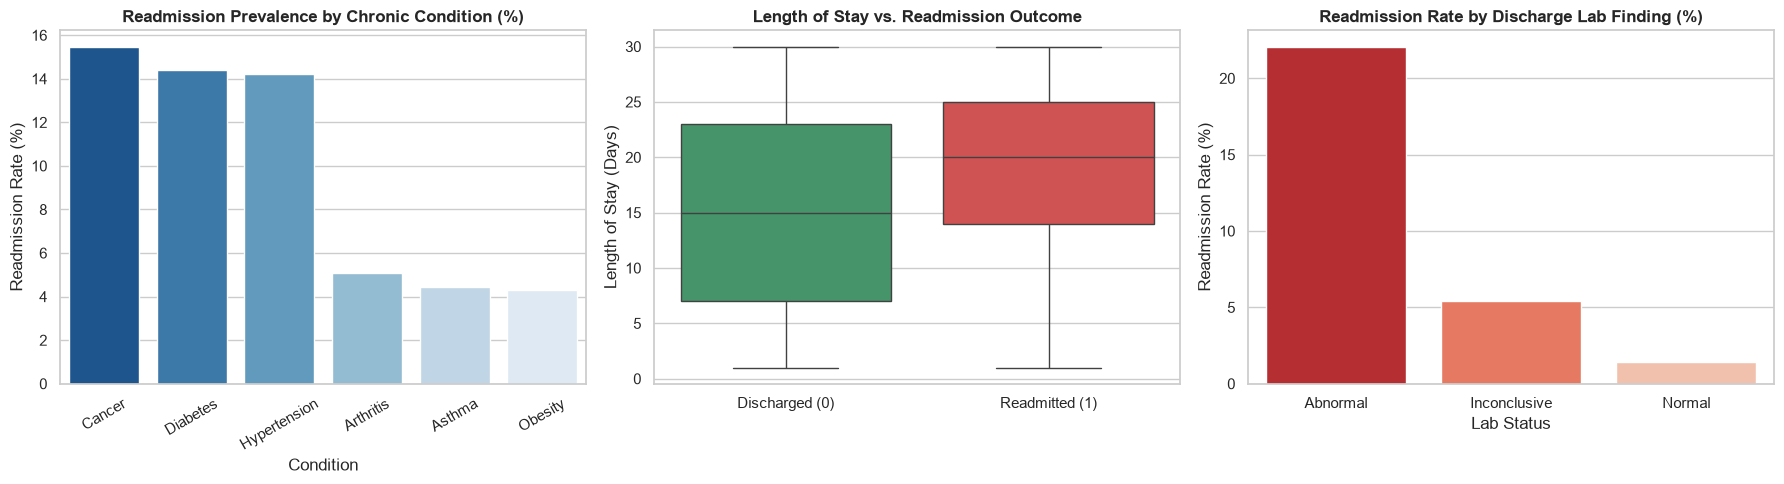

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Readmission by Chronic Medical Condition
cond_rates = df.groupby('medical_condition')['readmission'].mean().sort_values(ascending=False) * 100
sns.barplot(x=cond_rates.index, y=cond_rates.values, ax=axes[0], palette="Blues_r")
axes[0].set_title("Readmission Prevalence by Chronic Condition (%)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Readmission Rate (%)")
axes[0].set_xlabel("Condition")
axes[0].tick_params(axis='x', rotation=30)

# 2. Inpatient Length of Stay Distribution by Outcome
sns.boxplot(x='readmission', y='length_of_stay', data=df, ax=axes[1], palette=['#38A169', '#E53E3E'])
axes[1].set_title("Length of Stay vs. Readmission Outcome", fontsize=12, fontweight='bold')
axes[1].set_xticklabels(['Discharged (0)', 'Readmitted (1)'])
axes[1].set_ylabel("Length of Stay (Days)")
axes[1].set_xlabel("")

# 3. Lab Discharge Results Impact
test_rates = df.groupby('test_results')['readmission'].mean().sort_values(ascending=False) * 100
sns.barplot(x=test_rates.index, y=test_rates.values, ax=axes[2], palette="Reds_r")
axes[2].set_title("Readmission Rate by Discharge Lab Finding (%)", fontsize=12, fontweight='bold')
axes[2].set_ylabel("Readmission Rate (%)")
axes[2].set_xlabel("Lab Status")

plt.tight_layout()
plt.show()

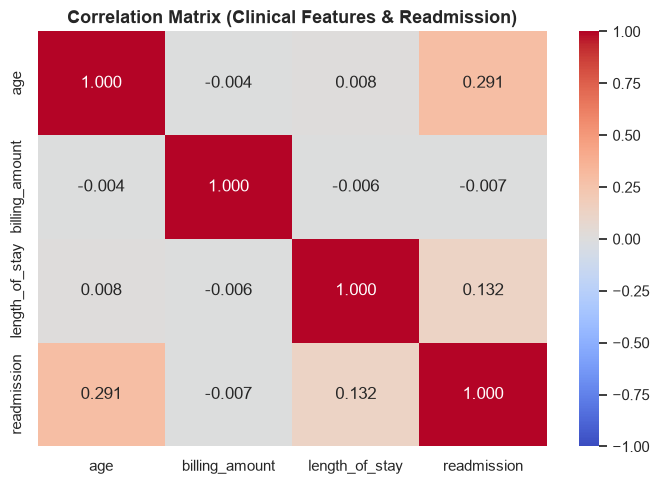

In [5]:
# Compute correlation on continuous predictors and readmission flag
corr_features = ['age', 'billing_amount', 'length_of_stay', 'readmission']
corr_matrix = df[corr_features].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".3f", cbar=True, vmin=-1, vmax=1)
plt.title("Correlation Matrix (Clinical Features & Readmission)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()